In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/complaints.csv")


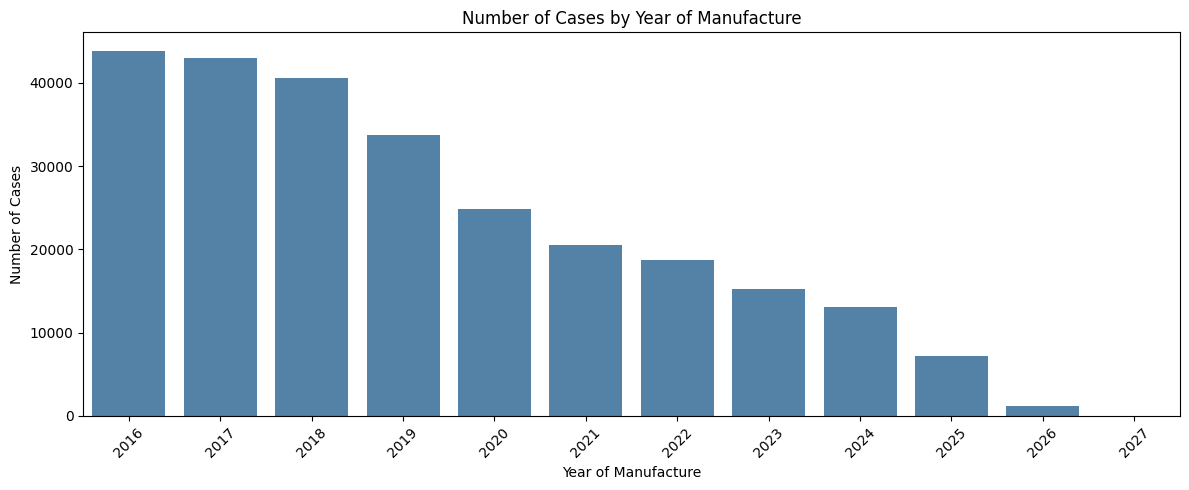

In [11]:
df_byModelYear = df.groupby("modelYear").size().reset_index(name="count").sort_values("modelYear")

plt.figure(figsize=(12, 5))
sns.barplot(data=df_byModelYear, x="modelYear", y="count", color="steelblue")
plt.xticks(rotation=45)
plt.xlabel("Year of Manufacture")
plt.ylabel("Number of Cases")
plt.title("Number of Cases by Year of Manufacture")
plt.tight_layout()
plt.show()

In [ ]:
component_by_year = (
    df[["modelYear", "components"]]
    .dropna(subset=["modelYear", "components"])
    .assign(
        modelYear=lambda frame: pd.to_numeric(frame["modelYear"], errors="coerce"),
        components=lambda frame: frame["components"].str.split(r"\s*[,/]\s*"),
    )
    .dropna(subset=["modelYear"])
    .explode("components")
)

component_by_year["components"] = component_by_year["components"].str.strip()
component_by_year = component_by_year[
    component_by_year["components"].notna() & (component_by_year["components"] != "")
]

component_by_year = (
    component_by_year.groupby(["modelYear", "components"]).size().reset_index(name="count")
)

print(component_by_year.head(20))

    modelYear                          components  count
0        2016                                 AIR     31
1        2016                            AIR BAGS   2643
2        2016                BACK OVER PREVENTION    444
3        2016                                Base      2
4        2016                              Buckle      8
5        2016                          CHILD SEAT      4
6        2016                        Carry Handle      2
7        2016                          Chest Clip      8
8        2016                              DIESEL    113
9        2016                            ELECTRIC      1
10       2016                   ELECTRICAL SYSTEM   7105
11       2016  ELECTRONIC STABILITY CONTROL (ESC)    826
12       2016                              ENGINE  10758
13       2016           ENGINE AND ENGINE COOLING   1003
14       2016                           EQUIPMENT    118
15       2016                  EQUIPMENT ADAPTIVE      5
16       2016                  

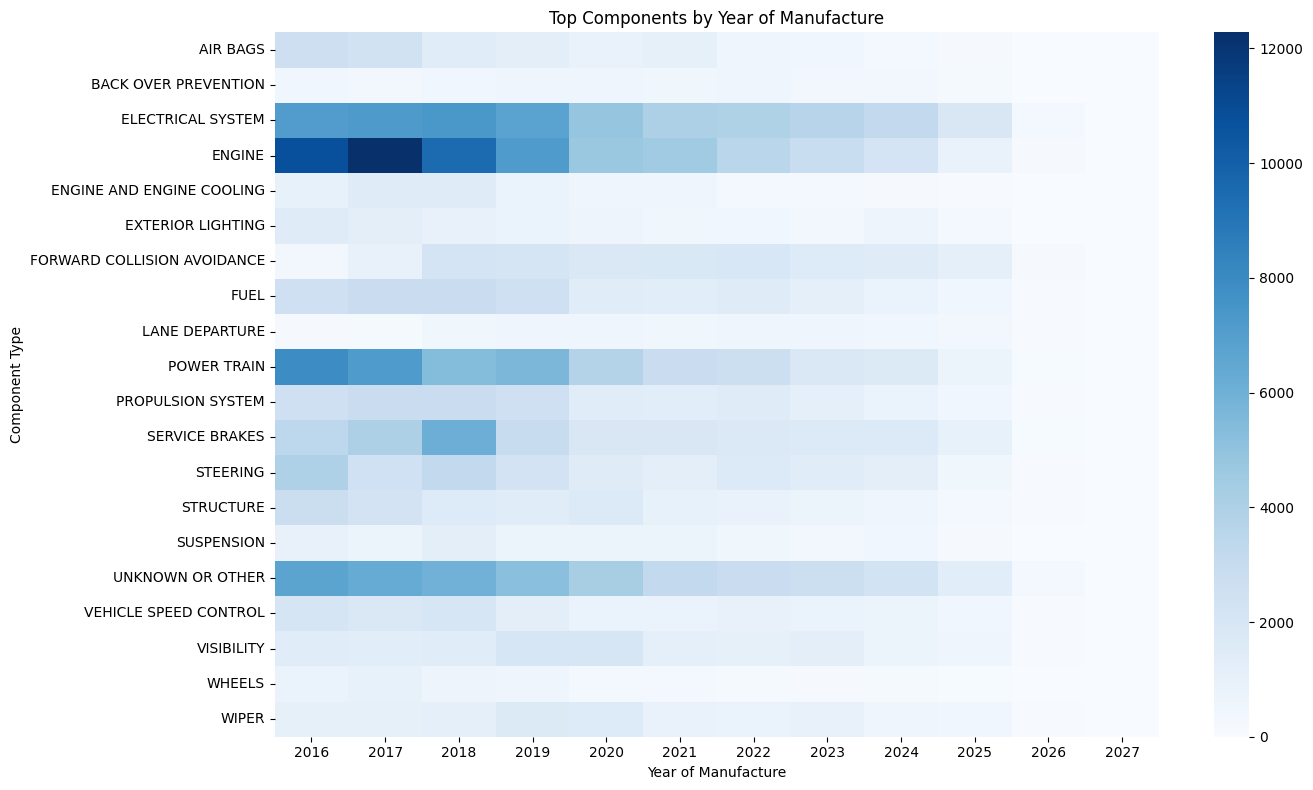

In [ ]:
top_components = (
    component_by_year.groupby("components")["count"]
    .sum()
    .nlargest(20)
    .index
)

component_by_year_top = component_by_year[
    component_by_year["components"].isin(top_components)
]

component_pivot = (
    component_by_year_top.pivot_table(
        index="components",
        columns="modelYear",
        values="count",
        fill_value=0,
    )
    .sort_index()
)

plt.figure(figsize=(14, 8))
sns.heatmap(component_pivot, cmap="Blues")
plt.xlabel("Year of Manufacture")
plt.ylabel("Component Type")
plt.title("Top Components by Year of Manufacture")
plt.tight_layout()
plt.show()